# Evaluation of sentiment classification

This notebook measures how accurate the project’s sentiment model classification is. 
It uses the same model and the same `label()` logic as `03_rag.py`, 
but compares the predictions against a small, manually labelled sample.

## 1. Setup

In [61]:
# Model pipeline (identical to 03_rag.py) and sklearn metrics
from transformers import pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

## 2. Model & label() function

Just as in the project: `nlptown/bert-base-multilingual-uncased-sentiment` returns 1–5 stars, 
which are mapped to three classes (1–2 = negative, 3 = neutral, 4–5 = positive).

In [62]:
# Multilingual BERT (uncased), input limited to 512 tokens
mood = pipeline("sentiment-analysis",
                model="nlptown/bert-base-multilingual-uncased-sentiment",
                truncation=True, max_length=512)

def labeling(text):
    result = mood(text)
    stars = int(result[0]["label"][0])   # The first digit consists of asterisks
    if stars <= 2:
        return "negative"
    if stars == 3:
        return "neutral"
    return "positive"

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 9308.94it/s]


## 3. Manually labelled sample

A small sample of mixed German and English text (corresponding to the DE/EN corpus). 
Note: Due to the small sample size, the result is only a rough guide.

In [63]:
samples = [
    # --- negative ---
    ("Lufthansa cancels hundreds of flights as strike grounds passengers", "negative"),
    ("Massive Verspätungen und Chaos an deutschen Flughäfen nach Streik", "negative"),
    ("Passengers furious over lost luggage and poor service", "negative"),
    ("Airline reports steep quarterly loss amid rising fuel costs", "negative"),
    ("Kundin beschwert sich über stundenlange Wartezeit in der Hotline", "negative"),
    # --- neutral ---
    ("Die Fluggesellschaft veröffentlicht ihren Quartalsbericht am Donnerstag", "neutral"),
    ("Der Quartalsbericht hat die mittlere Prognose wiedergegeben", "neutral"),
    ("Die Airline betreibt eine durchschnittliche Verbindung zwischen Frankfurt und Lissabon", "neutral"),
    ("Das Unternehmen nennt den 3 Sterne Catering-Anbieter für das Bordcatering", "neutral"),
    # --- positive ---
    ("Lufthansa reports record profit and raises full-year outlook", "positive"),
    ("Passagiere loben den freundlichen Service und pünktliche Abflüge", "positive"),
    ("Airline wins award for best business class in Europe", "positive"),
    ("Neue Sitze und besseres WLAN begeistern die Kunden", "positive"),
]

texts = []   # just the texts
label = []  # the corresponding target labels

for text, labled in samples:
    texts.append(text)
    label.append(labled)
    
print(f"{len(samples)} Examples loaded")

13 Examples loaded


## 4. Generate forecasts

Run the same function on all sample texts as you would in production.

In [64]:
preds = [labeling(t) for t in texts]

# True/False: Choice of model
for i in range(len(texts)):

    text = texts[i]
    true_label = label[i]
    predicted_label = preds[i]

    if true_label == predicted_label:
        mark = "OK    "
    else:
        mark = "FALSE "

    short_text = text[:60]
    print(f"{mark} label={true_label:<8} pred={predicted_label:<8} | {short_text}")

OK     label=negative pred=negative | Lufthansa cancels hundreds of flights as strike grounds pass
OK     label=negative pred=negative | Massive Verspätungen und Chaos an deutschen Flughäfen nach S
OK     label=negative pred=negative | Passengers furious over lost luggage and poor service
OK     label=negative pred=negative | Airline reports steep quarterly loss amid rising fuel costs
OK     label=negative pred=negative | Kundin beschwert sich über stundenlange Wartezeit in der Hot
FALSE  label=neutral  pred=positive | Die Fluggesellschaft veröffentlicht ihren Quartalsbericht am
OK     label=neutral  pred=neutral  | Der Quartalsbericht hat die mittlere Prognose wiedergegeben
OK     label=neutral  pred=neutral  | Die Airline betreibt eine durchschnittliche Verbindung zwisc
OK     label=neutral  pred=neutral  | Das Unternehmen nennt den 3 Sterne Catering-Anbieter für das
OK     label=positive pred=positive | Lufthansa reports record profit and raises full-year outlook
OK     label=positi

## 5. Metrics

`classification_report` returns precision, recall and F1 score for each class (plus **Macro-F1**)

In [65]:
labels = ["negative", "neutral", "positive"]
print(classification_report(label, preds, labels=labels, digits=3, zero_division=0))

              precision    recall  f1-score   support

    negative      1.000     1.000     1.000         5
     neutral      1.000     0.750     0.857         4
    positive      0.800     1.000     0.889         4

    accuracy                          0.923        13
   macro avg      0.933     0.917     0.915        13
weighted avg      0.938     0.923     0.922        13



## 6. Confusion Matrix

Shows which classes are being confused (e.g. neutral ↔ positive). 
Rows = true class, columns = predicted class.

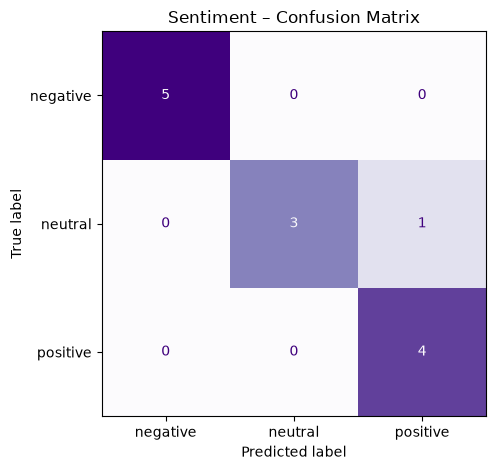

In [66]:
cm = confusion_matrix(label, preds, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Purples", colorbar=False)
plt.title("Sentiment – Confusion Matrix")
plt.tight_layout()
plt.savefig("outputs/senti_plot.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Interpretation

- If accuracy is high but Macro-F1 is low, the model performs poorly at recognising the rare class.
- The confusion matrix highlights typical errors, often **neutral ↔ positive**, because factual reports are classified as slightly positive by the star rating model.

**Note:** As mentioned at the beginning, this is a small sample and is intended merely as an illustration.